<a href="https://colab.research.google.com/github/emilyalway1/BohorquezLab/blob/main/April2026_T1RKO_Males.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Program for reading data files from the Intellicage and plotting consumption and specific preferences.**
(Written by Alam Coss, 2024)

Load the Visits.txt and Nosepokes.txt file from your Intellicage Session into the Files section

<=== Usually on the left, just drag and drop the files.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns
#from scipy.signal import savgol_filter
from datetime import datetime,timedelta
from statistics import mean
import colorsys
# Read the text file into a DataFrame called "visits"
file_path1 = "/content/drive/MyDrive/Bohorquez Lab/IntelliCage files/Social-experiment/Males mixed genotype sucrose sucralose/Visits.txt"  # Replace with the actual file path
file_path2 = "/content/drive/MyDrive/Bohorquez Lab/IntelliCage files/Social-experiment/Males mixed genotype sucrose sucralose/Nosepokes.txt"  # Replace with the actual file path
visits = pd.read_csv(file_path1, header=0, sep='\t')
nosepokes = pd.read_csv(file_path2, header=0, sep='\t')
visits

,VisitID,AnimalTag,Start,End,ModuleName,Cage,Corner,CornerCondition,PlaceError,AntennaNumber,AntennaDuration,PresenceNumber,PresenceDuration,VisitSolution,LickNumber,LickContactTime,LickDuration
0,0,3790161,2025-09-27 14:57:46.858,2025-09-27 14:58:05.002,Default,1,3,0,0,1,18.143479,1,18.687552,0,0,0.0,0.0
1,1,3786747,2025-09-27 14:58:03.946,2025-09-27 14:58:17.369,Default,1,2,0,0,1,13.423556,1,13.631512,0,0,0.0,0.0
2,2,3790161,2025-09-27 14:58:08.842,2025-09-27 14:58:22.489,Default,1,4,0,0,1,13.455409,1,14.159384,0,0,0.0,0.0
3,4,3790161,2025-09-27 14:58:46.142,2025-09-27 14:58:58.766,Default,1,1,0,0,1,12.623427,1,14.415322,0,0,0.0,0.0
4,3,3786261,2025-09-27 14:58:30.681,2025-09-27 14:58:59.133,Default,1,3,0,0,3,25.758966,1,30.356776,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5252,5253,3785465,2025-09-29 14:56:26.429,2025-09-29 14:56:39.548,Default,1,1,0,0,1,13.119361,1,12.479423,0,0,0.0,0.0
5253,5249,3786261,2025-09-29 14:53:07.444,2025-09-29 14:56:47.686,Default,1,2,0,0,4,50.440385,1,219.922382,0,0,0.0,0.0
5254,5255,3786258,2025-09-29 14:57:30.855,2025-09-29 14:57:41.495,Default,1,2,0,0,2,9.663466,0,0.000000,3,0,0.0,0.0
5255,5256,3787221,2025-09-29 14:57:41.495,2025-09-29 14:57:54.198,Default,1,2,0,0,2,4.319784,0,0.000000,3,0,0.0,0.0


In [24]:
# Set the start and end datetimes
start_datetime_str = "2025-09-27 15:00:00"
end_datetime_str = "2025-09-29 15:00:00"

# Convert the input strings to datetime objects
start_datetime = datetime.strptime(start_datetime_str, '%Y-%m-%d %H:%M:%S')
end_datetime = datetime.strptime(end_datetime_str, '%Y-%m-%d %H:%M:%S')

# Filter the visits and nosepokes DataFrames based on the datetime range
visits = visits[(pd.to_datetime(visits['Start']) >= start_datetime) & (pd.to_datetime(visits['End']) <= end_datetime)]
nosepokes = nosepokes[(pd.to_datetime(nosepokes['Start']) >= start_datetime) & (pd.to_datetime(nosepokes['End']) <= end_datetime)]

print("DataFrames filtered successfully.")
visits

DataFrames filtered successfully.


,VisitID,AnimalTag,Start,End,ModuleName,Cage,Corner,CornerCondition,PlaceError,AntennaNumber,AntennaDuration,PresenceNumber,PresenceDuration,VisitSolution,LickNumber,LickContactTime,LickDuration
11,12,3790161,2025-09-27 15:00:03.345,2025-09-27 15:00:16.337,Default,1,3,0,0,3,10.511704,1,13.439436,0,0,0.0,0.0
12,13,3786258,2025-09-27 15:00:20.864,2025-09-27 15:00:44.162,Default,1,3,0,0,1,19.439497,1,23.394105,0,0,0.0,0.0
13,14,3787221,2025-09-27 15:00:43.058,2025-09-27 15:00:45.778,Default,1,1,0,0,1,2.719851,1,2.466950,0,0,0.0,0.0
15,15,3786224,2025-09-27 15:00:55.922,2025-09-27 15:01:01.266,Default,1,2,0,0,1,5.103792,1,5.353764,0,0,0.0,0.0
16,17,3786261,2025-09-27 15:01:04.594,2025-09-27 15:01:16.890,Default,1,3,0,0,2,11.231537,1,12.632008,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5252,5253,3785465,2025-09-29 14:56:26.429,2025-09-29 14:56:39.548,Default,1,1,0,0,1,13.119361,1,12.479423,0,0,0.0,0.0
5253,5249,3786261,2025-09-29 14:53:07.444,2025-09-29 14:56:47.686,Default,1,2,0,0,4,50.440385,1,219.922382,0,0,0.0,0.0
5254,5255,3786258,2025-09-29 14:57:30.855,2025-09-29 14:57:41.495,Default,1,2,0,0,2,9.663466,0,0.000000,3,0,0.0,0.0
5255,5256,3787221,2025-09-29 14:57:41.495,2025-09-29 14:57:54.198,Default,1,2,0,0,2,4.319784,0,0.000000,3,0,0.0,0.0


In [25]:
# Read the animal information file
animal_info_path = input("Please enter the path to the animal information file (.txt): ")
animal_info_df = pd.read_csv(animal_info_path, header=0, sep='\t')
animal_info_df = animal_info_df.reset_index()
animal_info_df.columns = ['AnimalName', 'AnimalTag', 'Sex', 'GroupName', 'AnimalNotes', '']
animal_info_df.drop(columns=[''], inplace=True)
animal_info_df

Please enter the path to the animal information file (.txt): /content/drive/MyDrive/Bohorquez Lab/IntelliCage files/Social-experiment/Males mixed genotype sucrose sucralose/Animals.txt


,AnimalName,AnimalTag,Sex,GroupName,AnimalNotes
0,()204,3785825,Male,T1RKO,NaN
1,()203,3787045,Male,T1RKO,NaN
2,(3)224,3786083,Male,T1RKO,NaN
3,(1)202,3786261,Male,T1RKO,NaN
4,vGlut1KO(7)252,3787132,Male,WT,NaN
5,tdTomato(3)208,3789952,Male,WT,NaN
6,CckAR-KO()238-239,3787221,Male,WT,NaN
7,CckAR-K()236-237,3785443,Male,WT,NaN
8,()221,3786747,Male,T1RKO,NaN
9,(2)225,3790161,Male,T1RKO,NaN


In [ ]:
#animal_info_df['GroupName'] = 'KO'
#animal_info_df.columns

Index(['AnimalName', 'AnimalTag', 'Sex', 'GroupName', 'AnimalNotes'], dtype='object')

In [26]:
# Merge nosepokes and visits based on VisitID to get AnimalTag
nosepokes = pd.merge(nosepokes, visits[['VisitID', 'AnimalTag']], on='VisitID', how='left')

# Merge nosepokes and animal_info_df based on AnimalTag to get AnimalName and GroupName
nosepokes = pd.merge(nosepokes, animal_info_df[['AnimalTag', 'AnimalName', 'GroupName']], on='AnimalTag', how='left')

# Reorder columns to place AnimalName and GroupName after AnimalTag
cols = nosepokes.columns.tolist()
animal_tag_index = cols.index('AnimalTag')
cols.insert(animal_tag_index + 1, cols.pop(cols.index('AnimalName')))
cols.insert(animal_tag_index + 2, cols.pop(cols.index('GroupName')))
nosepokes = nosepokes[cols]

# Display the updated nosepokes DataFrame
nosepokes

,VisitID,Start,End,Side,SideCondition,SideError,TimeError,ConditionError,LickNumber,LickContactTime,LickDuration,AirState,DoorState,LED1State,LED2State,LED3State,LickStartTime,AnimalTag,AnimalName,GroupName
0,12,2025-09-27 15:00:04.145,2025-09-27 15:00:04.865,5,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3790161.0,(2)225,T1RKO
1,12,2025-09-27 15:00:07.297,2025-09-27 15:00:07.329,5,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3790161.0,(2)225,T1RKO
2,12,2025-09-27 15:00:07.025,2025-09-27 15:00:07.473,6,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3790161.0,(2)225,T1RKO
3,13,2025-09-27 15:00:21.680,2025-09-27 15:00:23.392,5,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3786258.0,()222-223,T1RKO
4,13,2025-09-27 15:00:37.344,2025-09-27 15:00:37.488,6,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3786258.0,()222-223,T1RKO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19236,5254,2025-09-29 14:56:51.254,2025-09-29 14:56:51.654,2,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3786261.0,(1)202,T1RKO
19237,5254,2025-09-29 14:56:51.846,2025-09-29 14:56:52.870,2,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3786261.0,(1)202,T1RKO
19238,5254,2025-09-29 14:57:34.919,2025-09-29 14:57:34.951,1,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3786261.0,(1)202,T1RKO
19239,5254,2025-09-29 14:57:35.287,2025-09-29 14:57:35.495,1,0,0,0,0,0,0.0,0.0,0,0,0,0,0,NaN,3786261.0,(1)202,T1RKO


In [27]:
#bottleNames = ["Water", "Baseline", "Water", "Sucrose", "Water", "Fat", "Water", "Protein"]
bottleNames = ["Water", "", "Sucrose", "", "Sucralose", "", "", ""]

In [28]:
# Remove unnecessary columns
nosepokes = nosepokes.drop(['SideError', 'ConditionError','SideCondition','TimeError','AirState','DoorState','LED1State','LED2State','LED3State'], axis=1, errors='ignore')

# Replace 'Side' values
nosepokes['Side'] = nosepokes['Side'].replace({1: 'water', 3: 'sucrose', 5: 'sucralose', 2: 'empty', 4: 'empty', 6: 'empty', 7: 'empty',8:'empty'})
#nosepokes['Side'] = nosepokes['Side'].where(nosepokes['Side'].isin([2, 4, 6, 7, 8]), np.nan)

nosepokes

,VisitID,Start,End,Side,LickNumber,LickContactTime,LickDuration,LickStartTime,AnimalTag,AnimalName,GroupName
0,12,2025-09-27 15:00:04.145,2025-09-27 15:00:04.865,sucralose,0,0.0,0.0,NaN,3790161.0,(2)225,T1RKO
1,12,2025-09-27 15:00:07.297,2025-09-27 15:00:07.329,sucralose,0,0.0,0.0,NaN,3790161.0,(2)225,T1RKO
2,12,2025-09-27 15:00:07.025,2025-09-27 15:00:07.473,empty,0,0.0,0.0,NaN,3790161.0,(2)225,T1RKO
3,13,2025-09-27 15:00:21.680,2025-09-27 15:00:23.392,sucralose,0,0.0,0.0,NaN,3786258.0,()222-223,T1RKO
4,13,2025-09-27 15:00:37.344,2025-09-27 15:00:37.488,empty,0,0.0,0.0,NaN,3786258.0,()222-223,T1RKO
...,...,...,...,...,...,...,...,...,...,...,...
19236,5254,2025-09-29 14:56:51.254,2025-09-29 14:56:51.654,empty,0,0.0,0.0,NaN,3786261.0,(1)202,T1RKO
19237,5254,2025-09-29 14:56:51.846,2025-09-29 14:56:52.870,empty,0,0.0,0.0,NaN,3786261.0,(1)202,T1RKO
19238,5254,2025-09-29 14:57:34.919,2025-09-29 14:57:34.951,water,0,0.0,0.0,NaN,3786261.0,(1)202,T1RKO
19239,5254,2025-09-29 14:57:35.287,2025-09-29 14:57:35.495,water,0,0.0,0.0,NaN,3786261.0,(1)202,T1RKO


In [29]:
# Remove rows where Side is 'empty'
nosepokes = nosepokes[(nosepokes['Side'] != 'empty')]

# Display the updated nosepokes DataFrame
nosepokes

,VisitID,Start,End,Side,LickNumber,LickContactTime,LickDuration,LickStartTime,AnimalTag,AnimalName,GroupName
0,12,2025-09-27 15:00:04.145,2025-09-27 15:00:04.865,sucralose,0,0.0,0.0,NaN,3790161.0,(2)225,T1RKO
1,12,2025-09-27 15:00:07.297,2025-09-27 15:00:07.329,sucralose,0,0.0,0.0,NaN,3790161.0,(2)225,T1RKO
3,13,2025-09-27 15:00:21.680,2025-09-27 15:00:23.392,sucralose,0,0.0,0.0,NaN,3786258.0,()222-223,T1RKO
5,13,2025-09-27 15:00:38.672,2025-09-27 15:00:38.704,sucralose,0,0.0,0.0,NaN,3786258.0,()222-223,T1RKO
6,13,2025-09-27 15:00:39.017,2025-09-27 15:00:39.199,sucralose,0,0.0,0.0,NaN,3786258.0,()222-223,T1RKO
...,...,...,...,...,...,...,...,...,...,...,...
19229,5255,2025-09-29 14:57:34.151,2025-09-29 14:57:35.799,sucrose,0,0.0,0.0,NaN,3786258.0,()222-223,T1RKO
19230,5255,2025-09-29 14:57:35.879,2025-09-29 14:57:36.167,sucrose,0,0.0,0.0,NaN,3786258.0,()222-223,T1RKO
19238,5254,2025-09-29 14:57:34.919,2025-09-29 14:57:34.951,water,0,0.0,0.0,NaN,3786261.0,(1)202,T1RKO
19239,5254,2025-09-29 14:57:35.287,2025-09-29 14:57:35.495,water,0,0.0,0.0,NaN,3786261.0,(1)202,T1RKO


In [30]:
# Convert 'Start' column to datetime objects
nosepokes['Start'] = pd.to_datetime(nosepokes['Start'])

# Set the time bin size (30 minutes)
time_bin_size = '30Min'

# Create a new column for time bins
nosepokes['TimeBin'] = nosepokes['Start'].dt.floor(time_bin_size)

# Group by AnimalTag, AnimalName, GroupName, TimeBin, and Side and sum the LickNumber
nosepokes_bins = nosepokes.groupby(['AnimalTag', 'AnimalName', 'GroupName', 'TimeBin', 'Side'])['LickNumber'].sum().reset_index()

# Display the new DataFrame
nosepokes_bins

/tmp/ipykernel_1547/3560784242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nosepokes['Start'] = pd.to_datetime(nosepokes['Start'])
/tmp/ipykernel_1547/3560784242.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nosepokes['TimeBin'] = nosepokes['Start'].dt.floor(time_bin_size)


,AnimalTag,AnimalName,GroupName,TimeBin,Side,LickNumber
0,3785443.0,CckAR-K()236-237,WT,2025-09-27 15:00:00,water,0
1,3785443.0,CckAR-K()236-237,WT,2025-09-27 15:30:00,sucralose,0
2,3785443.0,CckAR-K()236-237,WT,2025-09-27 17:00:00,water,0
3,3785443.0,CckAR-K()236-237,WT,2025-09-27 18:30:00,sucralose,0
4,3785443.0,CckAR-K()236-237,WT,2025-09-27 18:30:00,sucrose,359
...,...,...,...,...,...,...
1588,3790161.0,(2)225,T1RKO,2025-09-29 05:00:00,sucrose,287
1589,3790161.0,(2)225,T1RKO,2025-09-29 05:30:00,sucrose,0
1590,3790161.0,(2)225,T1RKO,2025-09-29 12:00:00,sucralose,0
1591,3790161.0,(2)225,T1RKO,2025-09-29 12:00:00,sucrose,0


In [31]:
# 2. Determine the overall time range for all animals
min_time = nosepokes_bins['TimeBin'].min()
max_time = nosepokes_bins['TimeBin'].max()

# 3. Generate the master list of 30-minute bins
all_bins = pd.date_range(start=min_time, end=max_time, freq=time_bin_size)

# 4. Extract the unique animal/side combos (no new combos introduced)
combos = (
    nosepokes_bins
      .loc[:, ['AnimalTag','AnimalName','GroupName','Side']]
      .drop_duplicates()
)

# 5. Cross-join combos with every time bin
combos['__key'] = 1
bins_df        = pd.DataFrame({'TimeBin': all_bins})
bins_df['__key'] = 1

full_grid = (
    combos
      .merge(bins_df, on='__key')
      .drop(columns='__key')
)

# 6. Left-merge your observed data onto the full grid
nosepokes_complete = (
    full_grid
      .merge(
          nosepokes_bins,
          on=['AnimalTag','AnimalName','GroupName','Side','TimeBin'],
          how='left'
      )
      .sort_values(['AnimalTag','Side','TimeBin'])
      .reset_index(drop=True)
)

# 7. Fill missing lick counts with zero
nosepokes_complete['LickNumber'] = nosepokes_complete['LickNumber'].fillna(0)

# Now you have every 30-minute TimeBin for each existing combo,
# with `LickNumber` = 0 where no data existed.

# 8. (Optional) Compute cumulative lick count per animal/side
nosepokes_complete['CumLickNumber'] = (
    nosepokes_complete
      .groupby(['AnimalTag','Side'])['LickNumber']
      .cumsum()
)

# Inspect
nosepokes_complete

,AnimalTag,AnimalName,GroupName,Side,TimeBin,LickNumber,CumLickNumber
0,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 15:00:00,0.0,0.0
1,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 15:30:00,0.0,0.0
2,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 16:00:00,0.0,0.0
3,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 16:30:00,0.0,0.0
4,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 17:00:00,0.0,0.0
...,...,...,...,...,...,...,...
4315,3790161.0,(2)225,T1RKO,water,2025-09-29 12:30:00,0.0,1471.0
4316,3790161.0,(2)225,T1RKO,water,2025-09-29 13:00:00,0.0,1471.0
4317,3790161.0,(2)225,T1RKO,water,2025-09-29 13:30:00,0.0,1471.0
4318,3790161.0,(2)225,T1RKO,water,2025-09-29 14:00:00,0.0,1471.0


In [32]:
import pandas as pd

# assume `df` is your completed DataFrame with columns:
# ['AnimalTag','AnimalName','GroupName','Side','TimeBin','LickNumber','CumLickNumber']

def zero_start(group):
    # get the first bin’s value
    offset = group['CumLickNumber'].iloc[0]

    # if it’s >0, subtract it from the whole series; otherwise leave unchanged
    if offset > 0:
        group['CumLickNumber'] = group['CumLickNumber'] - offset
    return group

# apply per AnimalTag & Side
nosepokes_bins_adjusted = (
    nosepokes_complete
      .sort_values(['AnimalTag','Side','TimeBin'])
      .groupby(['AnimalTag','Side'], group_keys=False)
      .apply(zero_start)
      .reset_index(drop=True)
)

# inspect
nosepokes_bins_adjusted


/tmp/ipykernel_1547/88825794.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(zero_start)


,AnimalTag,AnimalName,GroupName,Side,TimeBin,LickNumber,CumLickNumber
0,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 15:00:00,0.0,0.0
1,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 15:30:00,0.0,0.0
2,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 16:00:00,0.0,0.0
3,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 16:30:00,0.0,0.0
4,3785443.0,CckAR-K()236-237,WT,sucralose,2025-09-27 17:00:00,0.0,0.0
...,...,...,...,...,...,...,...
4315,3790161.0,(2)225,T1RKO,water,2025-09-29 12:30:00,0.0,1471.0
4316,3790161.0,(2)225,T1RKO,water,2025-09-29 13:00:00,0.0,1471.0
4317,3790161.0,(2)225,T1RKO,water,2025-09-29 13:30:00,0.0,1471.0
4318,3790161.0,(2)225,T1RKO,water,2025-09-29 14:00:00,0.0,1471.0


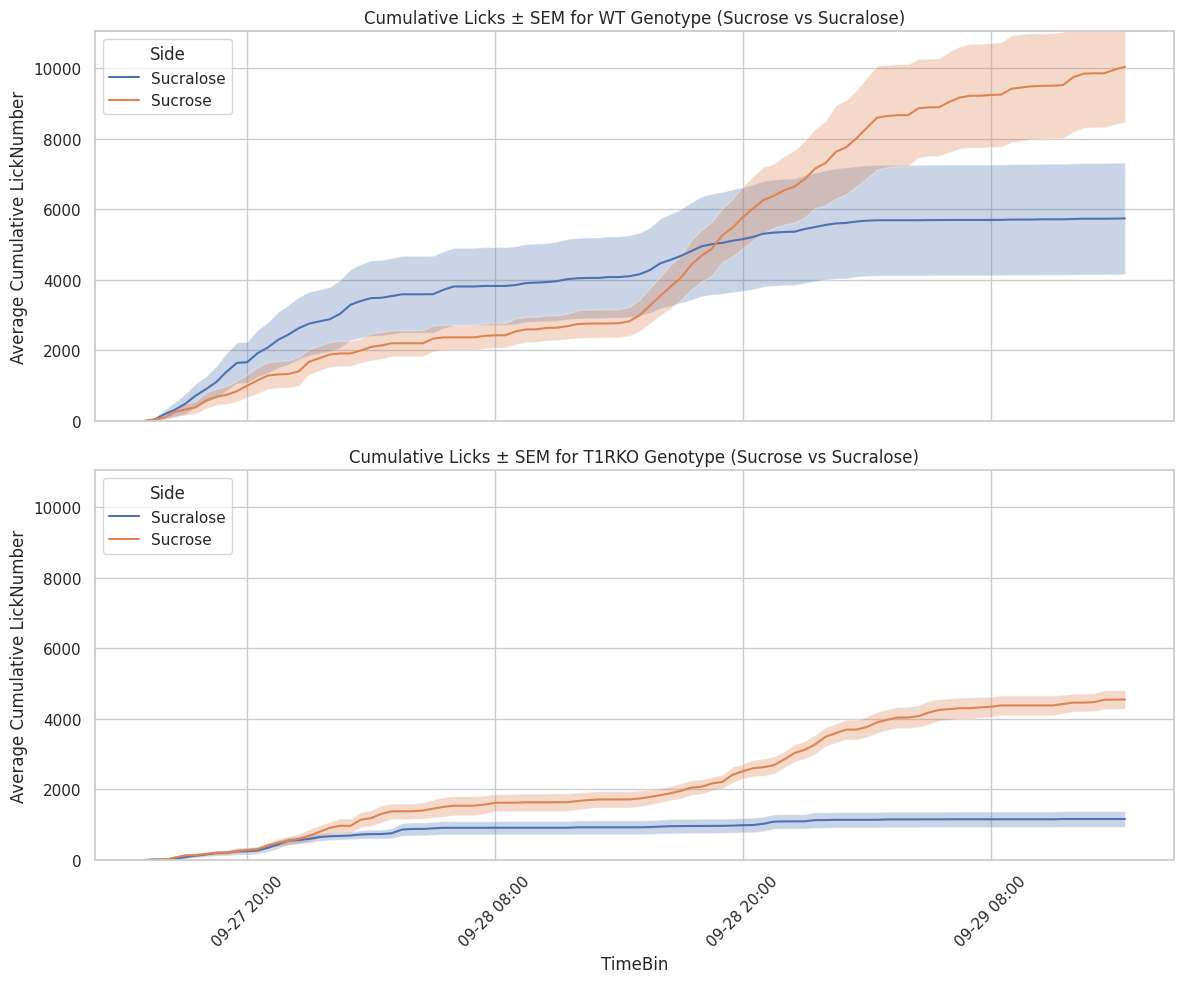

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the adjusted DataFrame
df_filtered_sides = nosepokes_bins_adjusted[nosepokes_bins_adjusted['Side'].isin(['sucrose', 'sucralose'])]

# Set up Seaborn style
sns.set(style="whitegrid")

# Get unique group names
group_names = df_filtered_sides['GroupName'].unique()

# Create subplots (one for each GroupName)
fig, axes = plt.subplots(nrows=len(group_names), ncols=1, figsize=(12, 5 * len(group_names)), sharex=True)

# Ensure axes is an array even if there's only one subplot
if len(group_names) == 1:
    axes = [axes]

# Determine the start time of the experiment
start_time = df_filtered_sides['TimeBin'].min()
end_time = df_filtered_sides['TimeBin'].max()

# Generate tick locations every 12 hours
import matplotlib.dates as mdates
hours = mdates.HourLocator(interval=12)
hours_fmt = mdates.DateFormatter('%m-%d %H:%M')

# Determine the overall maximum cumulative lick number to set a common y-axis limit
max_cum_licks = df_filtered_sides.groupby(['TimeBin', 'GroupName', 'Side'])['CumLickNumber'].mean().max() * 1.1 # Add 10% buffer


for ax, group in zip(axes, group_names):
    # Filter for this group
    df_group = df_filtered_sides[df_filtered_sides['GroupName'] == group]

    # Compute mean and SEM by TimeBin and Side for the cumulative sum
    summary = (
        df_group
        .groupby(['TimeBin', 'Side'])['CumLickNumber']
        .agg(mean='mean', sem='sem')
        .reset_index()
    )

    # Plot each side's line + SEM band
    for side in summary['Side'].unique():
        side_data = summary[summary['Side'] == side]
        ax.plot(side_data['TimeBin'], side_data['mean'], label=side.capitalize())
        ax.fill_between(
            side_data['TimeBin'],
            side_data['mean'] - side_data['sem'],
            side_data['mean'] + side_data['sem'],
            alpha=0.3
        )

    ax.set_title(f"Cumulative Licks ± SEM for {group} Genotype (Sucrose vs Sucralose)")
    ax.set_ylabel("Average Cumulative LickNumber")
    ax.legend(title="Side", loc="upper left")
    ax.xaxis.set_major_locator(hours)
    ax.xaxis.set_major_formatter(hours_fmt)
    ax.set_ylim(0, max_cum_licks)


# Final formatting
axes[-1].set_xlabel("TimeBin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
# Pivot the nosepokes_bins_adjusted DataFrame
nosepokes_pivot = nosepokes_bins_adjusted.pivot_table(
    index='TimeBin',
    columns=['GroupName', 'Side', 'AnimalName'],
    values='CumLickNumber'
)

# Sort columns by GroupName, then Side, then AnimalTag
nosepokes_pivot.sort_index(axis=1, inplace=True)

# Display the new DataFrame
nosepokes_pivot

GroupName               T1RKO                                                  \
Side                sucralose                                                   
AnimalName              ()203   ()204   ()205  ()221 ()222-223 (1)202  (2)225   
TimeBin                                                                         
2025-09-27 15:00:00       0.0     0.0     0.0    0.0       0.0    0.0     0.0   
2025-09-27 15:30:00     115.0     1.0     0.0    7.0       0.0    0.0     0.0   
2025-09-27 16:00:00     131.0     1.0     0.0    7.0       0.0    0.0     0.0   
2025-09-27 16:30:00     224.0    30.0     0.0    7.0       0.0    0.0     0.0   
2025-09-27 17:00:00     224.0    53.0   260.0   37.0       0.0   61.0     0.0   
...                       ...     ...     ...    ...       ...    ...     ...   
2025-09-29 12:30:00    1881.0  1217.0  2207.0  905.0     578.0  378.0  1317.0   
2025-09-29 13:00:00    1881.0  1217.0  2207.0  905.0     578.0  378.0  1317.0   
2025-09-29 13:30:00    1881.0  1217.0  2207.0  905.0     578.0  378.0  1317.0   
2025-09-29 14:00:00    1881.0  1217.0  2207.0  905.0     578.0  378.0  1317.0   
2025-09-29 14:30:00    1881.0  1217.0  2207.0  905.0     578.0  378.0  1317.0   

GroupName                                   ...                    WT  \
Side                       sucrose          ...               sucrose   
AnimalName          (3)224   ()203   ()204  ... Nd1_Slc5a1KO/KO(9)289   
TimeBin                                     ...                         
2025-09-27 15:00:00    0.0     0.0     0.0  ...                   0.0   
2025-09-27 15:30:00    0.0     0.0    19.0  ...                   0.0   
2025-09-27 16:00:00    0.0     0.0    19.0  ...                 314.0   
2025-09-27 16:30:00    2.0    17.0   123.0  ...                 686.0   
2025-09-27 17:00:00   13.0    17.0   264.0  ...                 978.0   
...                    ...     ...     ...  ...                   ...   
2025-09-29 12:30:00  817.0  4091.0  3609.0  ...               14526.0   
2025-09-29 13:00:00  817.0  4091.0  3609.0  ...               14526.0   
2025-09-29 13:30:00  817.0  4091.0  3609.0  ...               14526.0   
2025-09-29 14:00:00  817.0  4091.0  3640.0  ...               14526.0   
2025-09-29 14:30:00  817.0  4091.0  3640.0  ...               14526.0   

GroupName                                                           \
Side                                                         water   
AnimalName          tdTomato(3)208 vGlut1KO(7)252 CckAR-K()236-237   
TimeBin                                                              
2025-09-27 15:00:00            0.0            0.0              0.0   
2025-09-27 15:30:00            0.0            0.0              0.0   
2025-09-27 16:00:00            0.0            0.0              0.0   
2025-09-27 16:30:00            0.0            0.0              0.0   
2025-09-27 17:00:00            0.0            0.0              0.0   
...                            ...            ...              ...   
2025-09-29 12:30:00         3697.0         8674.0            364.0   
2025-09-29 13:00:00         3697.0         8750.0            364.0   
2025-09-29 13:30:00         3697.0         8750.0            364.0   
2025-09-29 14:00:00         3697.0         8750.0            364.0   
2025-09-29 14:30:00         3843.0         8759.0            364.0   

GroupName                                                    \
Side                                                          
AnimalName          CckAR-KO()238-239 Nd1_Slc5a1KO/KO(1)288   
TimeBin                                                       
2025-09-27 15:00:00               0.0                   0.0   
2025-09-27 15:30:00               0.0                   4.0   
2025-09-27 16:00:00               0.0                   4.0   
2025-09-27 16:30:00               0.0                  35.0   
2025-09-27 17:00:00               0.0                  35.0   
...                               ...                   ...   
2025-09

In [35]:
# Download the pivot table as a CSV file
nosepokes_pivot.to_csv('nosepokes_pivot_MalesT1RKO.csv')

print("The pivot table has been saved. You can download it from the files pane.")

The pivot table has been saved as 'nosepokes_pivot.csv'. You can download it from the files pane.
